In [2]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
ROOT_DIR = "/bettik/PROJECTS/pr-gin5_aini/fehrdelt/"

### Influence of timesteps and post processing

In [6]:
dice_scores_param_search_large_adc_csv = ROOT_DIR + "AnoDiffExperiments/experiment_2/exp_2_2_fixed/dice_scores_param_search_soop_large_group.csv"

In [7]:
dice_scores_param_search_df = pd.read_csv(dice_scores_param_search_large_adc_csv)

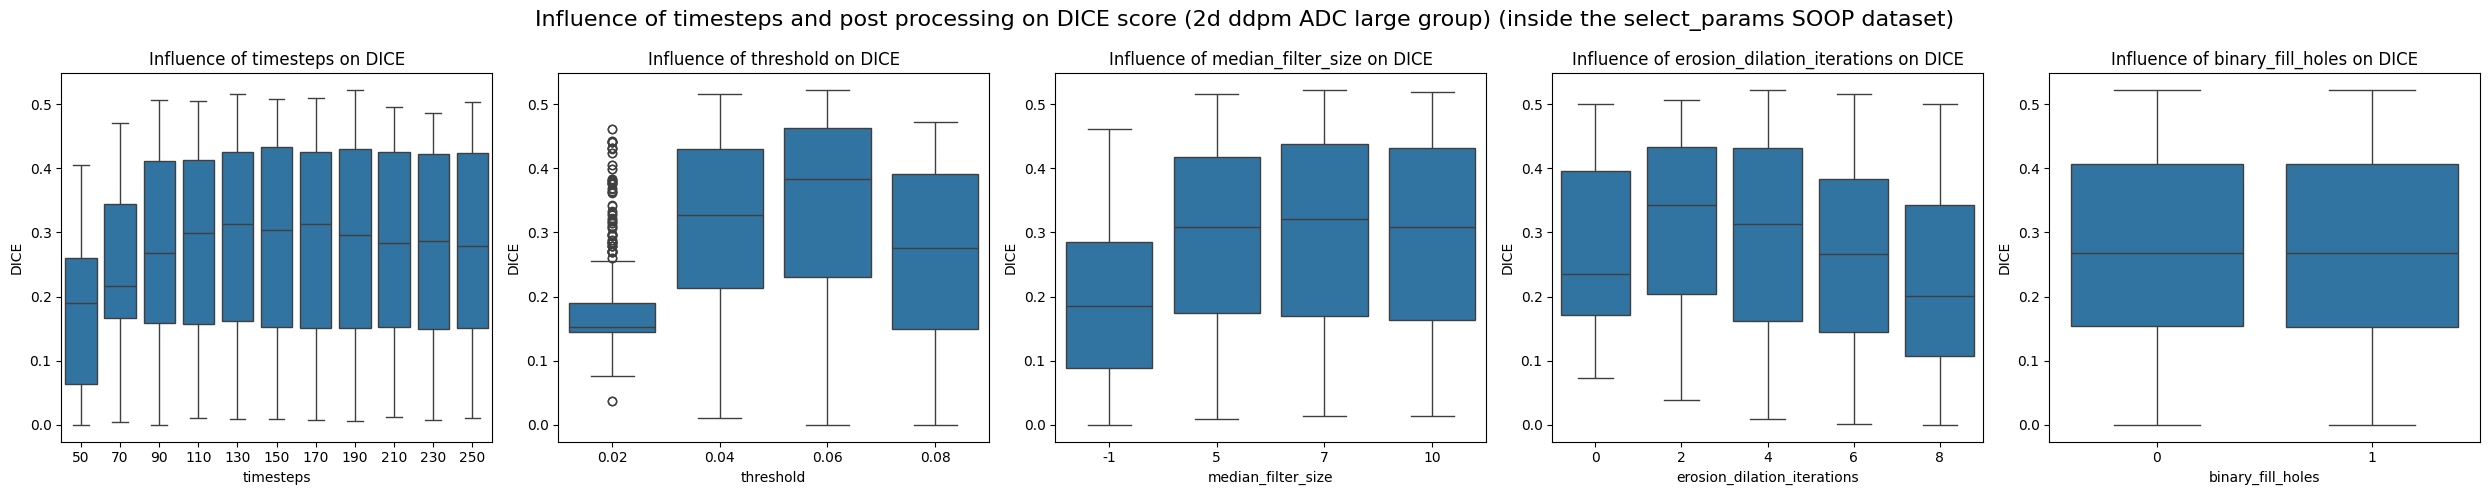

In [11]:
fig, axes = plt.subplots(1, 5, figsize=(25, 5))
columns = ['timesteps', 'threshold', 'median_filter_size', 'erosion_dilation_iterations', 'binary_fill_holes']

for i, col in enumerate(columns):
    sns.boxplot(data=dice_scores_param_search_df, x=col, y='DICE', ax=axes[i])
    axes[i].set_title(f'Influence of {col} on DICE')

plt.suptitle('Influence of timesteps and post processing on DICE score (2d ddpm ADC large group) (inside the select_params SOOP dataset)', fontsize=16)
plt.tight_layout()

plt.show()

### Influence of lesion size

In [12]:
dice_2d_ddpm_adc_large = {'mean':0.58,'90%CI': [0.53,0.64]}
dice_2d_ddpm_adc_medium = {'mean':0.34,'95%CI': [0.30,0.39]}
dice_2d_ddpm_adc_small = {'mean':0.07, '95%CI':[0.04,0.10]}

dice_2d_ddpm_flair_large = {'mean':0.52,'90%CI': [0.47,0.56]}
dice_2d_ddpm_flair_medium = {'mean':0.39,'95%CI': [0.35,0.43]}
dice_2d_ddpm_flair_small = {'mean':0.11, '95%CI':[0.09,0.15]}

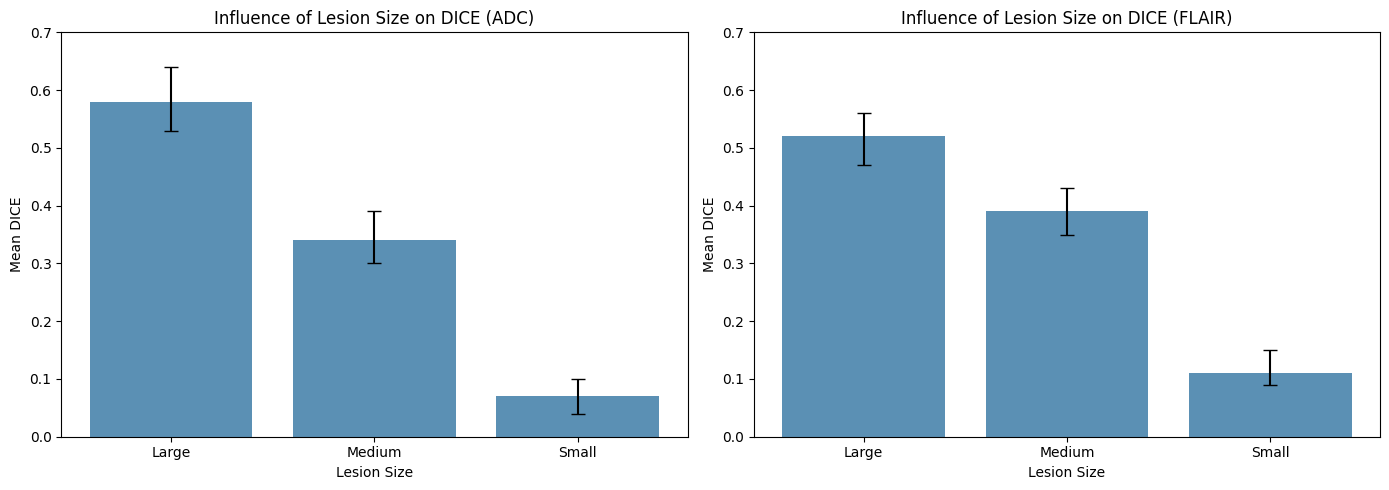

In [14]:
# Extract parameters
adc_data = [dice_2d_ddpm_adc_large, dice_2d_ddpm_adc_medium, dice_2d_ddpm_adc_small]
flair_data = [dice_2d_ddpm_flair_large, dice_2d_ddpm_flair_medium, dice_2d_ddpm_flair_small]

sizes = ['Large', 'Medium', 'Small']
adc_means = [d['mean'] for d in adc_data]
flair_means = [d['mean'] for d in flair_data]

# Calculate asymmetric error bars: [mean - lower, upper - mean]
adc_err = [
    [d['mean'] - d.get('95%CI', d.get('90%CI'))[0] for d in adc_data],
    [d.get('95%CI', d.get('90%CI'))[1] - d['mean'] for d in adc_data]
]

flair_err = [
    [d['mean'] - d.get('95%CI', d.get('90%CI'))[0] for d in flair_data],
    [d.get('95%CI', d.get('90%CI'))[1] - d['mean'] for d in flair_data]
]

# Create DataFrame for Seaborn
df_lesion = pd.DataFrame({
    'Lesion Size': sizes * 2,
    'Mean DICE': adc_means + flair_means,
    'Modality': ['ADC']*3 + ['FLAIR']*3
})

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ADC Plot
sns.barplot(data=df_lesion[df_lesion['Modality'] == 'ADC'], x='Lesion Size', y='Mean DICE', ax=axes[0], alpha=0.8)
axes[0].errorbar(x=range(3), y=adc_means, yerr=adc_err, fmt='none', c='black', capsize=5)
axes[0].set_title('Influence of Lesion Size on DICE (ADC)')
axes[0].set_ylim(0, 0.7)

# FLAIR Plot
sns.barplot(data=df_lesion[df_lesion['Modality'] == 'FLAIR'], x='Lesion Size', y='Mean DICE', ax=axes[1], alpha=0.8)
axes[1].errorbar(x=range(3), y=flair_means, yerr=flair_err, fmt='none', c='black', capsize=5)
axes[1].set_title('Influence of Lesion Size on DICE (FLAIR)')
axes[1].set_ylim(0, 0.7)

plt.tight_layout()
plt.show()